https://blog.djnavarro.net/posts/2023-04-12_metropolis-hastings/#the-problem

PDF to sample from:

$$p(x) = \frac{\exp(-x^2)(2+\sin(5x)+\sin(2x))}{\int_{-\infty}^{+\infty}\exp(-u^2)(2+\sin(5u) + \sin(2u))du}$$

Realistic knowledge about the target distribution is captured by the equation $$p(x) \propto \exp(-x^2)(2+\sin(5x)+\sin(2x))$$

How can I generate samples from this distribution?

# The Metropolis-Hastings Algorithm

The idea is to define a Markov chain over possible x values in such a way that the stationary distribution of the Markov chain is in fact $p(x)$. That is, what we're going to do is use a Markov chain to generate a sequence of x values, denoted $(x_0, x_1, x_2, \dots,x_n)$, in such a way that as $n \to \infty$, we can guarantee that $x_n \propto p(x)$. There are many different ways of setting up a Markov chain that has this property. The Metropolis-Hastings algorithm is one of these.

# The Proposal Step

Here's how it works. Suppose that the current state of the Markov chain is $x_n$, and we want to generate $x_{n+1}$ is a two-stage process.

The first stage is to generate a _candidate_, which we'll denote $x^*$. The value of $x^*$ is generated from the proposal distribution that we already know how to sample from. We denote this proposal distribution $q(x^*|x_n)$. Notice that the distribution we sample from depends on the current state of the Markov chain, $x_n$. There are some technical constraints on what you can use as a proposal distribution, but for the most part it can be anything you like. A very typical way to do this is to use a normal distribution centered on the current state $x_n$. More formally, we write this as: $$x^*|x_n \sim \text{Normal}(x_n, \sigma^2)$$

for some standard deviation $\sigma$ that we select in advance.

# The Accept-Reject Step

Firstly, what you neet to do is calculate the acceptance probability, denoted $A(x_n \to x^*)$, which is given by:
$$A((x_n \to x^*) = \min\left(1, \frac{p(x^*)}{p(x^n)} \times \frac{q(x_n|x^*)}{q(x^*|x_n)} \right).$$

There are two things to pay attention to here. Firstly, notice that the ratio $p(x^*)/p(x^n)$ doesn't depend on the normalising constant for the distribution. Or, to put it in a more helpful way, that integral in the first equation is completely irrelevant and we can ignore it. As a consequence, for our toy problem we can write this:

$$\frac{p(x^*)}{p(x^n)} = \frac{\exp(-{x^*}^2)(2+\sin(5x^*)+\sin(2x^*))}{\exp(-{x_n}^2)(2+\sin(5x_n)+\sin(2x_n))}$$

That's a nice simple thing to compute with no need for any numerical integration or, gods forbid, solving the integral analytically.

The second thing to pay attention to is the behaviour of the other term, $q(x_n|x^*)/q(x_n|x^*)$. What this term does is correct for any biases that the proposal distribution might induce. In this expression, the denominator $q(x^|x_n)$ describes the probability with which you'd choose $x^*$ as the candidate if the current state of the Marko chain is $x_n$. The numerator, however, describes the probability of a transition that goes the other way: that is, if the current state had actually been $x^*$  , what is the probability that you would have generated $x^n$ as the candidate value? If the proposal distribution is symmetric, then these two probabilities will turn out to be equal. For example, iff the proposal distribution is normal, then:

$$\begin{align}
q(x^*|x_n) = \frac{1}{\sqrt{2\pi} \sigma} \exp\left( -\frac{1}{2\sigma^2}(x_n - x^*)^2 \right)\\

q(x_n|(x^*) = \frac{1}{\sqrt{2\pi} \sigma} \exp\left( -\frac{1}{2\sigma^2}(x^* - x_n)^2 \right)

\end{align}$$

Clearly, they both are equal for all choices of $x^*|x_n$ and $x_n|x^*$.

Now, having proposed the candidate and calculated the acceptance probability, we no either decide to "accept" the candidate and set $x_{n+1} = x^*$  or we "reject" the candidate and set $x_{n+1} = x_n$. To make this decision, we generate a uniformly distributed random number between 0 and 1, denoted $u$. Then:
$$x_{n+1} = \begin{cases}
x^* \quad \text{if}\: u \leq A(x_n \to x^*)\\
x_n \quad \text{otherwise}

\end{cases}$$

In essence, this is the entirety of the Metropolis-Hastings algorithm!

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.stats import norm

In [8]:
def numerator(x):
    return np.exp(-x**2)*(2+np.sin(5*x)+np.sin(2*x))

def integrand(u):
    return np.exp(-u**2)*(2+np.sin(5*u)+np.sin(2*u))

def denominator():
    #integral from -inf to inf of integrand(u) du
    integral, _ = quad(integrand, -np.inf, np.inf)
    return integral

def pdf(x):
    return numerator(x)/denominator()

def known_pdf(x):
    return numerator(x)

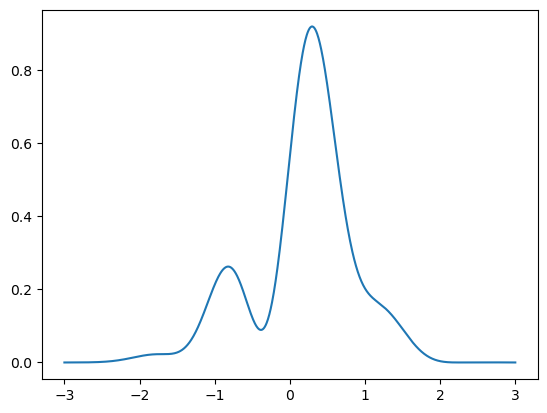

In [9]:
t = np.linspace(-3, 3, 1000)
pdf_values = pdf(t)
plt.plot(t, pdf_values)
plt.show()

In [4]:
#generate random number from a pdf with mean and std
def x_star(x_n, sigma):
    return np.random.normal(x_n, sigma)

def x_star_uniform(x_n, delta):
    return np.random.uniform(x_n - delta, x_n + delta)

x_star_binomial = lambda x_n, n: x_n + np.random.binomial(n, 0.5)*2 - n

#calculate acceptance probability for symmetrical proposal distribution
def acceptance_prob(x_n, x_star):
    return min(1, known_pdf(x_star)/known_pdf(x_n))

#symmetric metropolis-hastings algorithm loop for n steps
def metropolis_hastings(x_0, sigma, n, x_star = x_star_uniform):
    x_n = x_0
    samples = [x_n]
    for i in range(n):
        x_star_val = x_star(x_n, sigma)
        alpha = acceptance_prob(x_n, x_star_val)
        u = np.random.uniform(0, 1)
        if u < alpha:
            x_n = x_star_val
        samples.append(x_n)
    return np.array(samples)

In [19]:
def compute_hamiltonian_vectorized(pdf, x, p, M):
    U = -np.log(pdf(x))
    M_inv = np.inv(M)
    K = 0.5* p.T @ M_inv @ p
    return K, U

In [ ]:
class scalar_HMC():
    def __init__(self, pdf, M):
        self.pdf = pdf
        self.M = M
    def K(self, p):
        K = 0.5* p**2 / (2*self.M)
        return K

    def U(self, x):
        U = -np.log(self.pdf(x))
        return U

    def Ha(self, x, p):
        return -np.log(self.pdf(x)) + 0.5* p**2 / (self.M)
    
    def gradU(self, x, p, h):
        return (self.U(self.pdf,x+h, p, self.M)-self.U(self.pdf, x-h, p, self.M))/(2*h)
    
    def HMC(self, L, K, x0, epsilon):
        
        p = np.zeros(K)
        x = np.zeros(K)

        for k in range(K):
            p_prev = np.random.normal(0, 1)
            x_next = 
            for i in range(L):
                p_prev = p_prev + 0.5*epsilon*self.gradU(0.1)
                x_next = self.x + epsilon*p_prev
                p_prev = p_prev + 0.5*epsilon*self.gradU(0.1)
            alpha = np.random.uniform(0,1)
            acceptance_probability = np.min(1, -np.exp(-self.Ha(self.x, -self.p)+self.Ha(self.x, self.p)) )

            if alpha > acceptance_probability:
                p[k] = p_prev
                #x[k] = x_prev
            elif k > 0:
                p[k] = p[k-1]
                x[k] = x[k-1]

        return p, x
            

In [5]:
lahend1 = metropolis_hastings(0, 4, 20000)

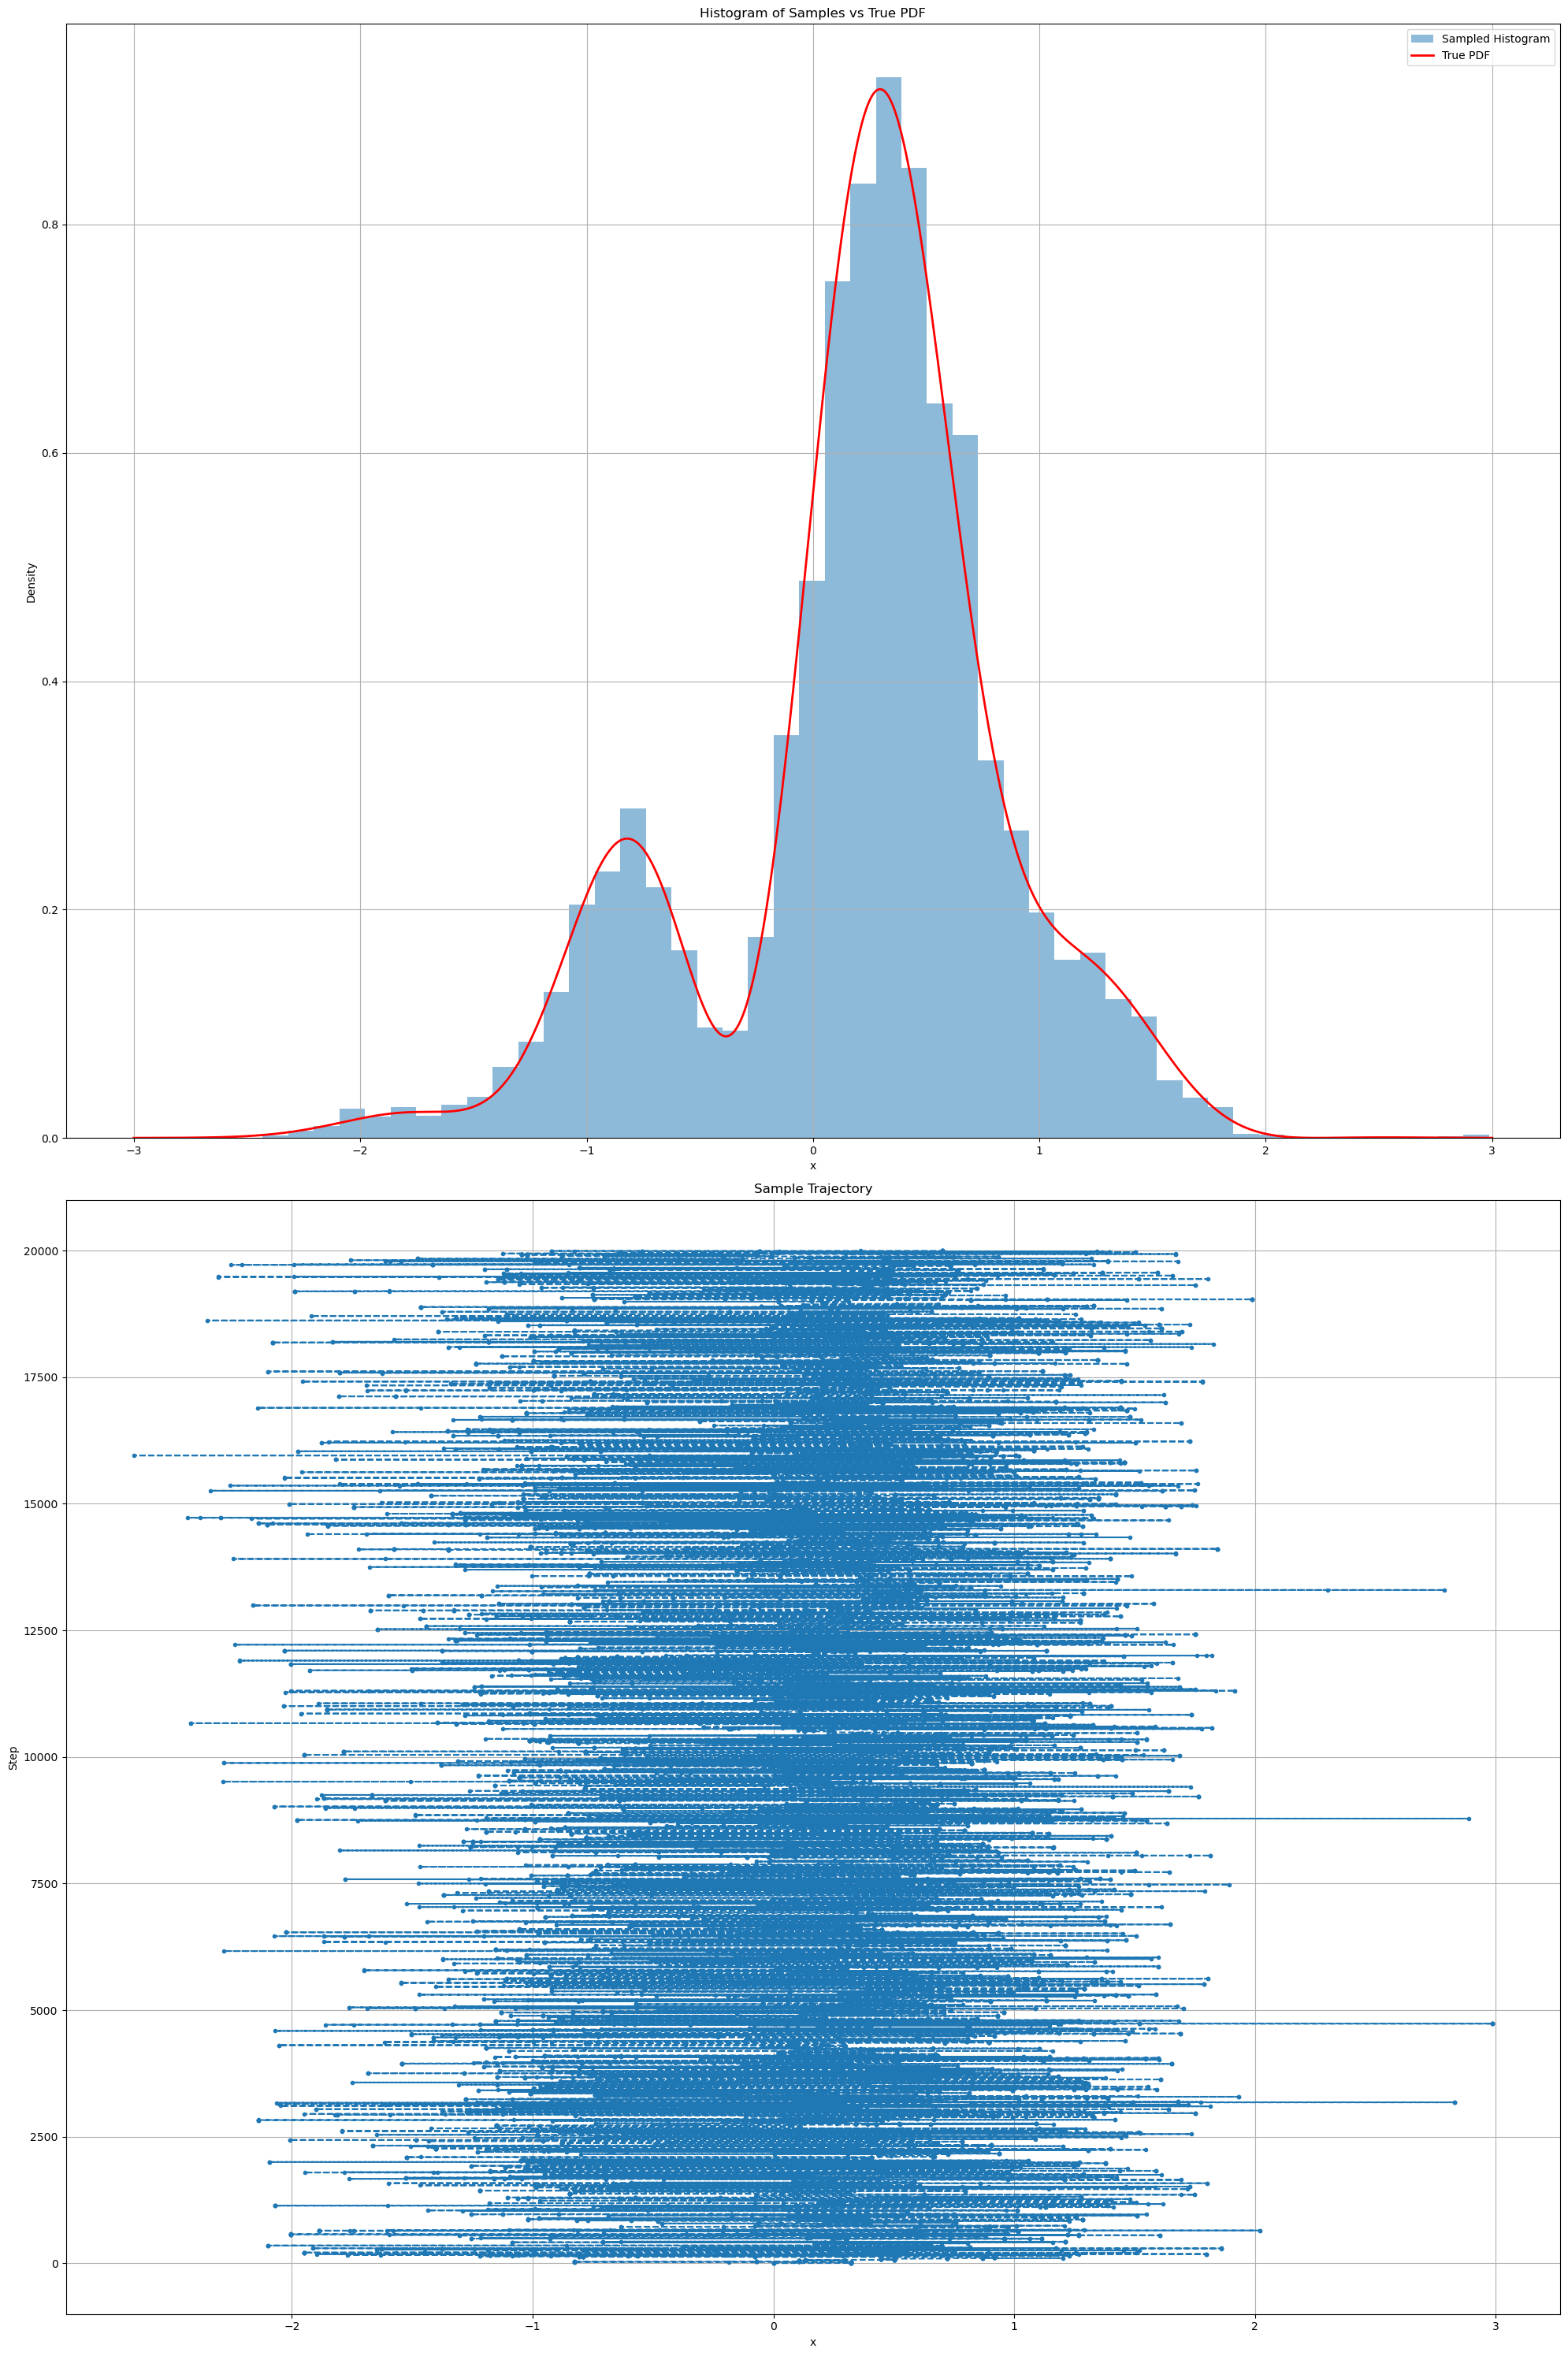

In [18]:
fig, ax = plt.subplots(2, 1, figsize=(20, 30))
#first we plot sample "trajectories" vertically and coincide them with histogram and pdf
ax[1].plot(lahend1[:len(lahend1)], np.arange(len(lahend1)), marker='o', linestyle='--', markersize=3)
ax[1].set_title('Sample Trajectory')
ax[1].set_xlabel('x')
ax[1].set_ylabel('Step')
ax[1].grid()
#then we plot histogram of samples and pdf
ax[0].hist(lahend1, bins=50, density=True, alpha=0.5, label='Sampled Histogram')
ax[0].plot(t, pdf_values, 'r-', lw=2, label='True PDF')
ax[0].set_title(f'Histogram of Samples vs True PDF')
ax[0].set_xlabel('x')
ax[0].set_ylabel('Density')
ax[0].legend()
ax[0].grid()

plt.tight_layout()
